In [ ]:
import pandas as pd
df = pd.read_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Agriculture/crop-yield.csv') # import df
print(df.columns.tolist()) # column names
# ['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture', 'Soil_Type', 'Organic_Carbon', 'Temperature', 'Humidity', 'Rainfall', 'Sunlight_Hours', 'Wind_Speed', 'Region', 'Altitude', 'Season', 'Crop_Type', 'Irrigation_Type', 'Fertilizer_Used', 'Pesticide_Used', 'Crop_Yield_ton_per_hectare']
print(df.head()) # head of data

## Which Crop_Type produces the highest average Crop_Yield_ton_per_hectare, and does Irrigation_Type significantly impact that yield?


In [ ]:
yield_max = df[df['Crop_Yield_ton_per_hectare'] == df['Crop_Yield_ton_per_hectare'].max()]
yield_max

In [ ]:
crops = df.groupby(['Season', 'Soil_Type', 'Crop_Type']).agg( # groupby season soil_type and crop_type
    Avg_Yield=('Crop_Yield_ton_per_hectare', 'mean') # make the avg_yield column
).reset_index() # reset the index

crops_max =( crops # df created above
.loc[crops.groupby(['Season', 'Soil_Type']) # loc these two columns
['Avg_Yield'] .idxmax()]) # max of this column crated above
crops_max # show the max

In [ ]:
df['Crop_Type'].unique()

cluster

In [33]:
crop_keep = 'Potato'
data=(
    df
#    [df['Crop_Type'] == crop_keep]
)

var1 = 'Fertilizer_Used'
var2 = 'Pesticide_Used'
Constant = crop_keep

In [34]:
## k-means
from sklearn.cluster import KMeans
tocluster=data[[var1,var2]]
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(tocluster)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [35]:
#Apply CH to Different Numbers of Clusters:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
tocluster=data[[var1,var2]]
for i in range(2,7):
  kmeans = KMeans(n_clusters=i,random_state=42)
  kmeans.fit(tocluster)
  ch_score = calinski_harabasz_score(tocluster, kmeans.labels_)
  print("Calinski–Harabasz Index for",i,"clusters:", ch_score)

Calinski–Harabasz Index for 2 clusters: 29346.82309715542
Calinski–Harabasz Index for 3 clusters: 37273.26330816516
Calinski–Harabasz Index for 4 clusters: 44181.04436662449
Calinski–Harabasz Index for 5 clusters: 50585.28323397986
Calinski–Harabasz Index for 6 clusters: 54667.11536464404


In [36]:
#Continuing with 5 clusters
from sklearn.cluster import KMeans
tocluster=data[[var1,var2]]
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(tocluster)
clusters = kmeans.predict(tocluster)

In [37]:
#Look at cluster membership
data['cluster'] = clusters.tolist()
print(data)

#cluster summary
p1=data.pivot_table(index="cluster",values=[var1,var2],aggfunc="mean")
p2=data.pivot_table(index="cluster",values=[Constant],aggfunc="count")
print("Cluster Means \n",p1)
print("\n \n Number of, {Constant}, per Cluster \n",p2)

        N   P    K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0     132  62   22     6.35          59.78      Clay            0.43   
1     122  71   66     5.98          25.54     Sandy            0.65   
2      44  35  104     8.07          25.87     Sandy            0.79   
3     136  96  113     4.83          42.97      Silt            0.45   
4     101  34   42     5.84          48.01      Silt            0.69   
...   ...  ..  ...      ...            ...       ...             ...   
9995   80  21   64     7.22          34.04     Loamy            0.85   
9996  168  36   36     6.45          56.84     Loamy            0.66   
9997  100  99   24     7.18          18.13     Sandy            0.54   
9998   68  20   63     6.32          53.47     Loamy            0.68   
9999   98  75   40     6.41          19.19     Loamy            0.58   

      Temperature  Humidity  Rainfall  ...   Region  Altitude  Season  \
0           22.97     53.89   1305.68  ...  Central        36 

KeyError: 'Potato'

C:\Users\tyler\AppData\Local\Temp\ipykernel_18220\3546445236.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Clusters"]=clusters


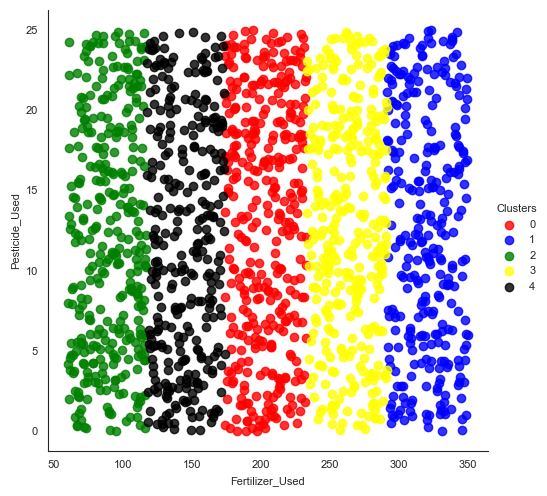

In [31]:
#plotting clusters
import seaborn as sns
import matplotlib.pyplot as plt
data["Clusters"]=clusters
#set font size of labels on matplotlib plots
plt.rc('font', size=8)
sns.set_style('white')
#set the colors used in the graph, see https://xkcd.com/color/rgb/
customPalette = ['red', 'blue', 'green', 'yellow', 'black' ]
sns.set_palette(customPalette)
#plot data with seaborn
facet = sns.lmplot(data=data, x=var1, y=var2, hue='Clusters',
fit_reg=False, legend=True)
